In [1]:
try:
    import lightgbm as lgb
except:
    %pip install -q -U lightgbm
    import lightgbm as lgb

lgb.__version__

'4.6.0'

In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device: CPU 4 cores


In [3]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random
from scipy.optimize import minimize

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

## -- Machine Learning --
import sklearn
from sklearn.base import clone
from sklearn.frozen import FrozenEstimator
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, LabelEncoder, LabelBinarizer
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score, log_loss

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [4]:
## -- Global Settings --
# sklearn.set_config(transform_output='pandas')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RED':    '\033[35m',
    'RESET':  '\033[0m',
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e6/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
    test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

    ORIG_PATH = '/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/'
    orig = pd.read_csv(ORIG_PATH+'star_classification.csv')#.drop(['customerID'], axis=1)
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e4 | Irrigation Need/_irrigation_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv').drop('id', axis=1)
    test = pd.read_csv(PATH+'test.csv').drop('id', axis=1)
    orig = pd.read_csv(PATH+'irrigation_prediction.csv')#.drop(['customerID'], axis=1)

## =================================================================================

TARGET = train.columns[-1]
CATS   = ['spectral_type', 'galaxy_population']

NUMS   = [c for c in train.columns if c not in CATS+[TARGET, 'id']]
BASE   = NUMS + CATS

mapping = {c: i for i, c in enumerate(train[TARGET].unique())}
r_mapping = {i: c for i, c in enumerate(train[TARGET].unique())}

for df in [train, orig]:
    df[TARGET] = df[TARGET].map(mapping)

for (name, df) in [('Train', train), ('Test', test), ('Original', orig)]:
    print(f"{name} shape: {df.shape}")

print(f"\nTotal nums: {len(NUMS)}")
print(f"Total cats: {len(CATS)}")
print(f"Total base: {len(BASE)}")

Train shape: (577347, 11)
Test shape: (247435, 10)
Original shape: (100000, 18)

Total nums: 8
Total cats: 2
Total base: 10


In [6]:
display(train.head())
train.info()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,0
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,0
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,1
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,0
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   alpha              577347 non-null  float64
 1   delta              577347 non-null  float64
 2   u                  577347 non-null  float64
 3   g                  577347 non-null  float64
 4   r                  577347 non-null  float64
 5   i                  577347 non-null  float64
 6   z                  577347 non-null  float64
 7   redshift           577347 non-null  float64
 8   spectral_type      577347 non-null  object 
 9   galaxy_population  577347 non-null  object 
 10  class              577347 non-null  int64  
dtypes: float64(8), int64(1), object(2)
memory usage: 48.5+ MB


In [7]:
train.describe() 

,alpha,delta,u,g,r,i,z,redshift,class
count,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135,0.489465
std,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070,0.732431
min,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970,0.000000
25%,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052,0.000000
50%,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525,0.000000
75%,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390,1.000000
max,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780,2.000000


In [8]:
## -- ['spectral_type', 'galaxy_population'] derivation for original data --
def spectral_type(g, r):
    return pd.cut(
        r-g, 
        [-np.inf, -1, -0.5, 0, np.inf],
        labels=['M', 'G/K', 'A/F', 'O/B']
    ).astype(str)

def galaxy_population(u, r):
    return pd.cut(
        u-r, 
        [-np.inf, 2.2, np.inf],
        labels=['Blue_Cloud', 'Red_Sequence']
    ).astype(str)

orig['spectral_type'] = spectral_type(orig.g, orig.r)
orig['galaxy_population'] = galaxy_population(orig.u, orig.r)

orig

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,spectral_type,galaxy_population
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,0,0.634794,5812,56354,171,M,Red_Sequence
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,0,0.779136,10445,58158,427,A/F,Blue_Cloud
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,0,0.644195,4576,55592,299,M,Red_Sequence
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,0,0.932346,9149,58039,775,M,Blue_Cloud
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,0,0.116123,6121,56187,842,M,Red_Sequence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1.237679e+18,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,7778,301,2,581,1.055431e+19,0,0.000000,9374,57749,438,M,Blue_Cloud
99996,1.237679e+18,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,7917,301,1,289,8.586351e+18,0,0.404895,7626,56934,866,M,Red_Sequence
99997,1.237668e+18,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,5314,301,4,308,3.112008e+18,0,0.143366,2764,54535,74,M,Red_Sequence
99998,1.237661e+18,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,3650,301,4,131,7.601080e+18,0,0.455040,6751,56368,470,M,Red_Sequence


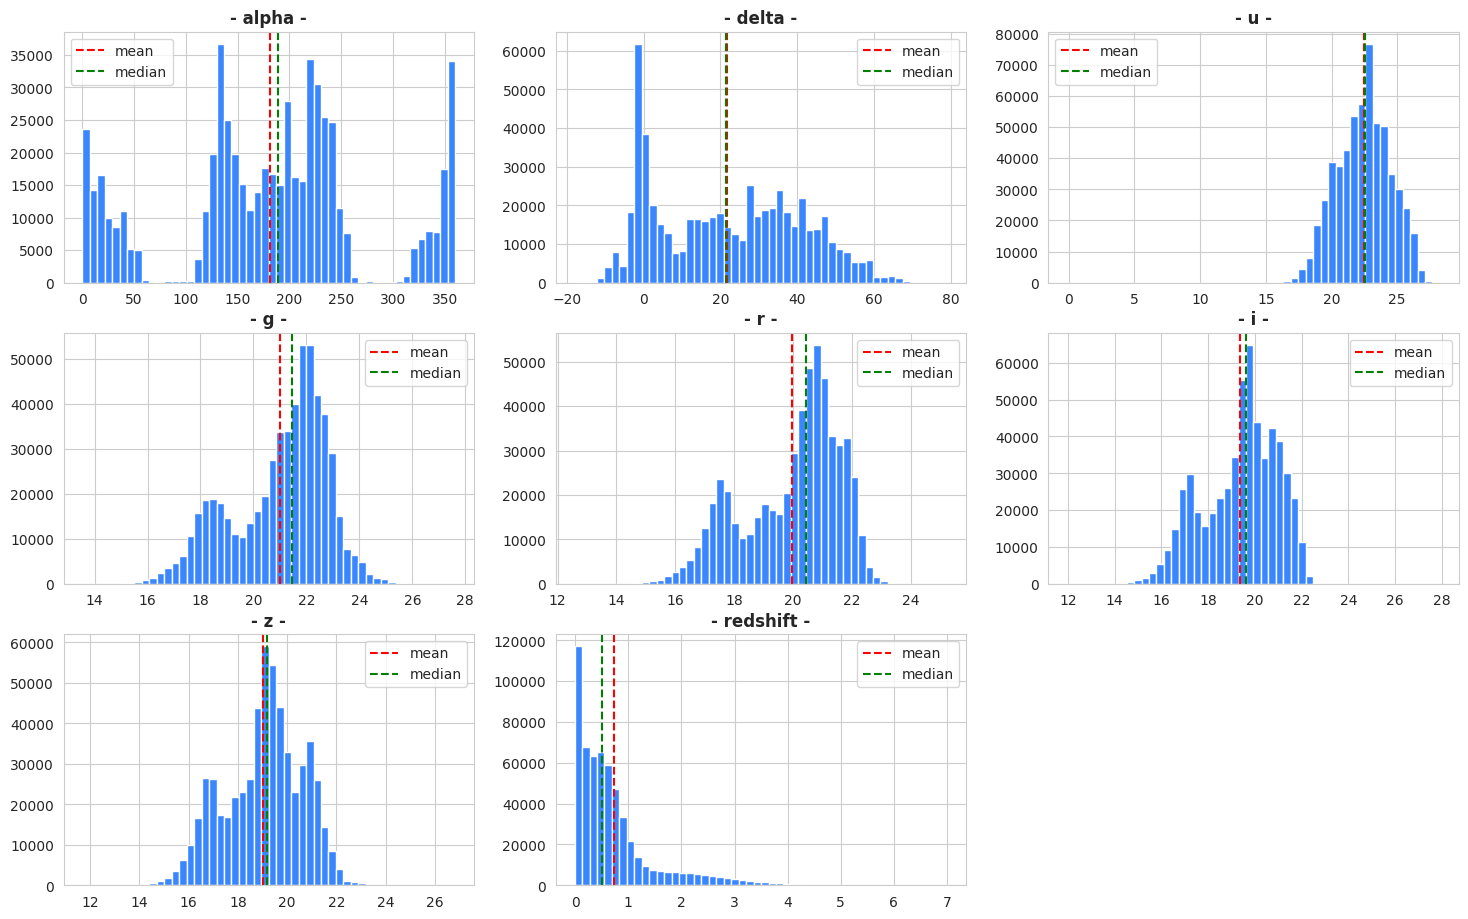

In [9]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='g', linestyle='--', label='median')
    plt.title(f'- {col} -', fontweight='semibold')
    plt.legend()
    
plt.show()

In [10]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
Train,439819,444062,577347,577347,577347,577347,577347,573975,4,2
Original,99999,99999,93748,92651,91901,92019,92007,99295,4,2
Test,200893,201819,247435,247435,247435,247435,247435,246031,4,2


## FEATURE ENGINEERING

In [11]:
def get_class_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        return opt
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        return dict(zip(classes_, weights_))

def get_sample_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        return np.array([opt[label] for label in y])
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        return np.array([class_weights[label] for label in y])

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

def t_enc_multi(X_tr, X_va, X_ts, y_tr, cols, drop=False):
    X_tr_1 = X_tr.copy()
    X_va_1 = X_va.copy()
    X_ts_1 = X_ts.copy()

    te_enc = TargetEncoder(target_type='multiclass', random_state=CFG['SEED']).set_output(transform='pandas')

    X_tr_te = te_enc.fit_transform(X_tr_1[cols], y_tr)
    X_va_te = te_enc.transform(X_va_1[cols])
    X_ts_te = te_enc.transform(X_ts_1[cols])

    te_names = [f"_TE_{c}" for c in X_tr_te.columns]
    X_tr_1[te_names] = X_tr_te
    X_va_1[te_names] = X_va_te
    X_ts_1[te_names] = X_ts_te

    if drop:
        X_tr_1 = X_tr_1.drop(columns=cols)
        X_va_1 = X_va_1.drop(columns=cols)
        X_ts_1 = X_ts_1.drop(columns=cols)

    return X_tr_1, X_va_1, X_ts_1

print('- Helper Functions Ready -')

- Helper Functions Ready -


In [12]:
from sklearn.inspection import permutation_importance

def plot_permutation_importance(model, X, y, categories):
    for c in categories:
        X[c] = X[c].factorize()[0]
        X[c] = X[c].astype('category')
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)

    ## -- Train Model --
    print('Training base model... ', end='')
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_test, y_test)],
        # sample_weight=get_weights(y_train, y)
    )

    model_importances = pd.Series(model.feature_importances_, index=X.columns)
    preds = model.predict_proba(X_test)
    score = balanced_acc(y_test, preds)
    print('Complete!', end='')
    print(f" • Balanced_Accuracy: {score:.5f}")

    ## -- Compute Permutation Importances --
    print('Training permutation... ', end='')
    result = permutation_importance(
        model, X_test, y_test,
        n_repeats=5, # max_samples=0.8,
        # sample_weight=get_weights(y_test, y),
        scoring='balanced_accuracy',
        random_state=42, n_jobs=-1,
    )
    perm_sorted_idx = result.importances_mean.argsort()
    print('Complete!')

    fig, axs = plt.subplots(1, 2, figsize=(16, 0.35*len(X.columns)))
    model_importances.sort_values().plot.barh(ax=axs[0])
    axs[0].set_xlabel("Model importance")

    axs[1].boxplot(
        result.importances[perm_sorted_idx].T,
        orientation='horizontal',
        tick_labels=X.columns[perm_sorted_idx],
        whis=(0, 100),
    )
    axs[1].axvline(x=0, color="k", linestyle="--")
    axs[1].set_xlabel("Permutaion Importance")

    _s_t = 'Model vs. Permutation on validation data'
    fig.suptitle(_s_t, y=1.00, fontweight='bold')
    _ = fig.tight_layout()

    df = pd.Series(dict(zip(
        X.columns[perm_sorted_idx],
        result.importances_mean[perm_sorted_idx].ravel()
    )))

    return df.nlargest(50, keep='all').to_frame('Importance Score')

print('Permutaion function script ready!')

Permutaion function script ready!


In [13]:
# %%time

# PARAMS = {
#     'objective': 'multiclass', # multiclass_ova
#     'metric': 'multiclass',
#     'num_classes': 3,
#     'class_weight': 'balanced',
#     'importace_type': 'gain',
#     'verbose': -1,
#     'nthreads': -1,
#     'random_state': CFG['SEED'],
#     'device': 'gpu' if torch.cuda.is_available() else 'cpu',
# }

# _model = lgb.LGBMClassifier(**PARAMS)

# top_features_df = plot_permutation_importance(
#     _model,
#     train.drop(columns=[TARGET]),
#     train[TARGET],
#     CATS,
# )

# top_features_df

In [14]:
# ## -- Optimal Binning --
# try:
#     import optbinning
# except:
#     %pip install -q -U optbinning
#     import optbinning

# def _opt_multiclass_binning(
#     x_tr, y_tr, x_vl, x_ts, bin_features,
#     solver='cp', metric='mean_woe', pre_bins=100, period=100):
#     """
#     metric: 'mean_woe' or 'weighted_mean_woe': floats or 'indices': integers
#     """
#     x_train = x_tr.copy()
#     x_valid = x_vl.copy()
#     x_test  = x_ts.copy()

#     opt_modules_per_col = []
#     opt_cols = []

#     for col in tqdm(bin_features, desc='Optimal_Multiclass_Binning'):
#         # print(f'{col}... ', end='')
#         opt_multi_b = optbinning.MulticlassOptimalBinning(
#             name=col,
#             prebinning_method='cart', # d='cart', 'quantile'
#             min_prebin_size=0.02, # d=0.05
#             max_n_prebins=pre_bins, # d=20
#             # min_n_bins=2, max_n_bins=100,
#             # min_bin_size=0.1, max_bin_size=0.9,
#             solver=solver,
#             time_limit=period, # d=100 (secs)
#             # verbose=True,
#         )

#         opt_multi_b.fit(x_train[col].to_numpy(), y_tr.to_numpy())
#         # display(optb.information(print_level=0))

#         new_col = f'{col}_optBin'
#         x_train.loc[:, new_col] = opt_multi_b.transform(x_train[col].to_numpy(), metric=metric)
#         x_valid.loc[:, new_col] = opt_multi_b.transform(x_valid[col].to_numpy(), metric=metric)
#         x_test.loc[:, new_col]  = opt_multi_b.transform(x_test[col].to_numpy(),  metric=metric)

#         opt_cols.append(new_col)
#         opt_modules_per_col.append(opt_multi_b)

#     # print(f'Done!')

#     return opt_modules_per_col, opt_cols, x_train, x_valid, x_test

# print('Binning function ready')

In [15]:
# opt_bins, opt_bin_cols, train2, orig2, test2 = _opt_multiclass_binning(
#     x_tr=train,
#     y_tr=train[TARGET],
#     x_vl=orig,
#     x_ts=test,
#     bin_features=NUMS,
#     solver='cp', # 'cp', 'mip', 'lr'
#     metric='mean_woe', # 'mean_woe','weighted_mean_woe','indices','bins'
#     pre_bins=100, 
#     period=100,
# )

# print(f"Total bin features: {len(opt_bin_cols)}")
# train2.head()

In [16]:
# BIN_TABLES = []

# for opt_ in opt_bins:
#     # print(opt_bins[col_n].status, opt_bins[col_n].splits)
#     opt_table = opt_.binning_table
#     opt_table.build()
#     # display(opt_table.build())
#     BIN_TABLES.append(opt_table)

# print('Optimal Binned Features:', len(BIN_TABLES))
# print('Classes:', BIN_TABLES[0].classes)

# ## -- Plot optimal bin points --
# for i, opt_ in enumerate(BIN_TABLES):
#     opt_.plot(show_bin_labels=True, figsize=(18, 5))
#     print()

In [17]:
# for col in opt_bin_cols:
#     print(f"{col}: {train2[col].nunique()}")

In [18]:
# BIN_TABLES[0].analysis()

In [19]:
BANDS = ['u', 'g', 'r', 'i', 'z']

ROUNDS = []
FLOORS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [20]:
for col in tqdm(['alpha', 'delta', 'redshift']):
    print(f"\nRounding... ", end='')
    for r in range(-3, 6):
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
        ## -- Drop irrelevant features --
        if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
            DROP_COLS.append(r_n)
        else:
            ROUNDS.append(r_n)

    # print(f"\nDigitizing... ", end='')
    # for d in range(-3, 7):
    #     d_n = f'{col}_digit_{d}'
    #     print(d_n+', ', end='')
    #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
    #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
    #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
    #     ## -- Drop constant features --
    #     if train[d_n].nunique() < digit_thresh:
    #         DROP_COLS.append(d_n)
    #     else:
    #         DIGITS.append(d_n)

    # print(f"\nEqual binning... ", end='')
    # for b in [32, 64, 128]: # 100, 500, 1000
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    # print(f"\nQuantile binning... ", end='')
    # for q in [32, 64, 128]:
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ ROUNDS: {len(ROUNDS)}')
print(f'✅ FLOORS: {len(FLOORS)}')
print(f"✅ DIGITS: {len(DIGITS)}")
print(f"✅ E_BINS: {len(E_BINS)}")
print(f"✅ Q_BINS: {len(Q_BINS)}")

  0%|          | 0/3 [00:00<?, ?it/s]


Rounding... alpha_round_-3, alpha_round_-2, alpha_round_-1, alpha_round_0, alpha_round_1, alpha_round_2, alpha_round_3, alpha_round_4, alpha_round_5, 
Rounding... delta_round_-3, delta_round_-2, delta_round_-1, delta_round_0, delta_round_1, delta_round_2, delta_round_3, delta_round_4, delta_round_5, 
Rounding... redshift_round_-3, redshift_round_-2, redshift_round_-1, redshift_round_0, redshift_round_1, redshift_round_2, redshift_round_3, redshift_round_4, redshift_round_5, 
✅ ROUNDS: 21
✅ FLOORS: 0
✅ DIGITS: 0
✅ E_BINS: 0
✅ Q_BINS: 0


In [21]:
# for col in tqdm(NUMS):
#     # print(f"\nRounding... ", end='')
#     # for r in range(-3, 6):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')
#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     print(f"\nFlooring... ", end='')
#         f_n = f"{col}_floor_"
#         print(f_n+', ', end='')
#         train[f_n] = np.floor(train[col].to_numpy()) #.astype('int32')
#         test[f_n]  = np.floor(test[col].to_numpy()) #.astype('int32')
#         orig[f_n]  = np.floor(orig[col].to_numpy()) #.astype('int32')
#         FLOORS.append(f_n)
#     # print(f"\nDigitizing... ", end='')
#     # for d in range(-3, 7):
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nEqual binning... ", end='')
#     # for b in [32, 64, 128]: # 100, 500, 1000
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nQuantile binning... ", end='')
#     # for q in [32, 64, 128]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ ROUNDS: {len(ROUNDS)}')
# print(f'✅ FLOORS: {len(FLOORS)}')
# print(f"✅ DIGITS: {len(DIGITS)}")
# print(f"✅ E_BINS: {len(E_BINS)}")
# print(f"✅ Q_BINS: {len(Q_BINS)}")

In [22]:
for col in ['delta']: # 'u', 'g', 'r', 'i', 'z',
    # print(f"\nRounding... ", end='')
    # for r in range(-3, 5):
    #     r_n = f"{col}_round_{r}"
    #     print(r_n+', ', end='')
    #     train[r_n] = train[col].round(r).astype('int32')
    #     test[r_n]  = test[col].round(r).astype('int32')
    #     orig[r_n]  = orig[col].round(r).astype('int32')
    #     ## -- Drop irrelevant features --
    #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
    #         DROP_COLS.append(r_n)
    #     else:
    #         ROUNDS.append(r_n)
    
    # print(f"\nExtracting digits... ", end='')
    # for d in range(-3, 6):
    #     d_n = f'{col}_digit_{d}'
    #     print(d_n+', ', end='')
    #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
    #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
    #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

    #     ## -- Drop constant features --
    #     if train[d_n].nunique() < digit_thresh:
    #         DROP_COLS.append(d_n)
    #     else:
    #         DIGITS.append(d_n)

    # print(f"\nEqual binning... ", end='')
    # for b in [100]: # 50, 100, 400
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     # Fit on train data and transform both train and test
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    print(f"\nQuantile binning.. ", end='')
    for q in [90, 180, 360]: 
        q_n = f'{col}_qbin_{q}_'
        print(q_n+', ', end='')
        train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
        test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ ROUNDS: {len(ROUNDS)}')
print(f'✅ FLOORS: {len(FLOORS)}')
print(f"✅ DIGITS: {len(DIGITS)}")
print(f"✅ E_BINS: {len(E_BINS)}")
print(f"✅ Q_BINS: {len(Q_BINS)}")


Quantile binning.. delta_qbin_90_, delta_qbin_180_, delta_qbin_360_, 
✅ ROUNDS: 21
✅ FLOORS: 0
✅ DIGITS: 0
✅ E_BINS: 0
✅ Q_BINS: 3


In [23]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

train[ROUNDS+FLOORS+DIGITS+E_BINS+Q_BINS].nunique()

Features dropped: ['alpha_round_-3', 'delta_round_-3', 'delta_round_-2', 'redshift_round_-3', 'redshift_round_-2', 'redshift_round_-1']


alpha_round_-2        5
alpha_round_-1       37
alpha_round_0       343
alpha_round_1       340
alpha_round_2       340
alpha_round_3       339
alpha_round_4       338
alpha_round_5       338
delta_round_-1       11
delta_round_0        95
delta_round_1        93
delta_round_2        92
delta_round_3        92
delta_round_4        92
delta_round_5        92
redshift_round_0      8
redshift_round_1      8
redshift_round_2      8
redshift_round_3      8
redshift_round_4      8
redshift_round_5      8
delta_qbin_90_       90
delta_qbin_180_     180
delta_qbin_360_     360
dtype: int64

In [24]:
# def add_frequency_condition(df1, cols, thresh=5):
#     df = df1.copy()
#     for c in cols:
#         # 1. Get value counts
#         v_counts = df[c].value_counts()
#         # 2. Identify values to replace (count <= threshold)
#         to_replace = v_counts[v_counts <= thresh].index
#         # 3. Apply condition: if value in low-freq list, assign 0, else keep it
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [25]:
# ## -- Arithmetic interaction --

# for df in tqdm([train, test, orig]):
#     df['u_g_sub_'] = df['u'] - df['g']
#     df['g_r_sub_'] = df['g'] - df['r']

#     df['g_i_sub_'] = df['g'] - df['i']
#     df['r_z_sub_'] = df['r'] - df['z']

#     df['i_z_sub_'] = df['i'] - df['z']
#     df['r_i_sub_'] = df['r'] - df['i']
#     df['u_z_sub_'] = df['u'] - df['z']
    
#     df['stellar_locus_dist'] = np.sqrt((df['g_r_sub_'] - 0.52)**2 + (df['r_i_sub_'] - 0.25)**2)

#     for band in ['g', 'i']:
#         b_col = f"_div_{band}_redshift"
#         df[b_col] = df[band] / (df['redshift'] + 1e-6)

# color_bands = [c for c in train.columns if c.endswith('_sub_') or c.endswith('_div_')]
# color_bands.append('stellar_locus_dist')

# train[color_bands].describe()

In [26]:
# ## -- Arithmetic interaction --
# color_pairs = [
#     ('u', 'g'),
#     ('g', 'r'),
#     ('i', 'z'),
#     ('r', 'z'),
#     ('u', 'z'),
# ]

# for df in tqdm([train, test, orig]):
#     df['_log_redshift'] = np.log1p(df['redshift']).astype('float32')
#     df['_div_g_redshift'] = (df['g'] / (df['redshift'] + 1e-6)).astype('float32')
#     df['_div_i_redshift'] = (df['i'] / (df['redshift'] + 1e-6)).astype('float32')

#     for a, b in tqdm(color_pairs):
#         df[f"_{a}_{b}"] = (df[a] - df[b]).astype('float32')

#     df['redshift_u_*_g'] = df['redshift'] * df['_u_g']
#     df['redshift_g_*_r'] = df['redshift'] * df['_g_r']

#     df['sky_dist'] = np.sqrt(df['alpha']**2 + df['delta']**2)

#     df[f"_div_abs_g_redshift"] = (df['g'] / (df['redshift'].abs() + 1e-6)).astype('float32')
#     df[f"_div_abs_i_redshift"] = (df['i'] / (df['redshift'].abs() + 1e-6)).astype('float32')

In [27]:
## -- Arithmetic interaction --
BANDS = ['u', 'g', 'r', 'i', 'z']

COLOR_PAIRS = [
    ('u', 'g'),
    ('g', 'r'),
    ('i', 'z'),
    ('r', 'z'),
    ('u', 'z'),
    ('r', 'i'),
]

for df in tqdm([train, test, orig]):
    for a, b in COLOR_PAIRS:
        df[f"_{a}_{b}"] = (df[a] - df[b]).astype('float32')

    for band in BANDS:
        df[f"_div_abs_{band}_redshift"] = (df[band] / (df['redshift'].abs() + 1e-6)).astype('float32')

    df['_log_redshift'] = np.log1p(df['redshift']).astype('float32')
    df['_sky_dist'] = np.sqrt(df['alpha']**2 + df['delta']**2)
    df['_stellar_locus_dist'] = np.sqrt((df['_g_r'] - 0.52)**2 + (df['_r_i'] - 0.25)**2)

    # df["_mean_bands"] = df[BANDS].mean(axis=1)
    # df["_std_bands"] = df[BANDS].std(axis=1)
    # df["_skew_bands"] = df[BANDS].skew(axis=1)
    # df["_max_bands"] = df[BANDS].max(axis=1)
    # df["_min_bands"] = df[BANDS].min(axis=1)
    # df["_range_bands"] = df["_max_bands"] - df["_min_bands"]

  0%|          | 0/3 [00:00<?, ?it/s]

In [28]:
## -- Cyclic encoding --

for df in tqdm([train, test, orig], desc="Cyclical features"):
    for col in ['alpha', 'delta']:
        for p in [180, 360]:
            df[f"{col}_sin_{p}"] = np.sin(2 * np.pi * df[col] / p).astype('float32')
            df[f"{col}_cos_{p}"] = np.cos(2 * np.pi * df[col] / p).astype('float32')

Cyclical features:   0%|          | 0/3 [00:00<?, ?it/s]

In [29]:
# ## -- Frequency encoding --
# freq_cols = []

# print(f"\nCreate frequencies... ", end='')
# for col in ['spectral_type']:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_freq'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     freq_cols.append(n)

# print()
# print(f"✅ Total frequency features: {len(freq_cols)}")

# train[freq_cols].head()

In [30]:
INTER = []

# alpha_rounds = [c for c in ROUNDS if 'alpha' in c]
# delta_rounds = [c for c in ROUNDS if 'delta' in c]
# red_rounds   = [c for c in ROUNDS if 'redshift' in c]

for c1, c2 in tqdm(list(itertools.combinations(CATS, 2)), desc='Pairwise'):
    n_col = f"_Bi_{c1}-|-{c2}"
    train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
    test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
    orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
    INTER.append(n_col)

# for c1, c2, c3 in tqdm(list(itertools.combinations(NUMS, 3)), desc='Triplewise'):
#     n_col = f"_Tri_{c1}-|-{c2}-|-{c3}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
#     INTER.append(n_col)

# for c1, c2 in tqdm(list(itertools.product(CATS, red_rounds)), desc='One-to-Many'):
#     n_col = f"_Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

print(f"Total interaction features: {len(INTER)}")

train[INTER].head()

Pairwise:   0%|          | 0/1 [00:00<?, ?it/s]

Total interaction features: 1


,_Bi_spectral_type-|-galaxy_population
0,M_Red_Sequence
1,M_Red_Sequence
2,O/B_Blue_Cloud
3,M_Red_Sequence
4,M_Red_Sequence


In [31]:
# ## -- Reduce data memory --
# def reduce_memory(df):
#     old_size = sys.getsizeof(df) / (1024*1024)
#     for c in tqdm(df.columns, desc='Reducing memory...'):
#         ## -- Downcast Integer type ---
#         if df[c].dtype == np.int64: 
#             if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
#                 df[c] = df[c].astype(np.int32)
#                 # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
#                 #     df[c] = df[c].astype(np.int16)
#                 #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
#                 #         df[c] = df[c].astype(np.int8)
#         ## -- Downcast Float type -----
#         # elif df[c].dtype == np.float64:
#         #     if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
#         #         df[c] = df[c].astype(np.float32)
#                 # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
#                 #     df[c] = df[c].astype(np.float16)

#     new_size = sys.getsizeof(df) / (1024*1024)
#     print(f"Size before process: {old_size:.1f}MB")
#     print(f"Size after process : {new_size:.1f}MB\n")
    
#     return df

# train = reduce_memory(train)
# test = reduce_memory(test)
# orig = reduce_memory(orig)

# gc.collect()

# print(f"Data memory reduced!")

In [32]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== CategoryMeanEncoder =====

class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        cat_cols = cat_cols
        mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if cat_cols is None:
            cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        mappings_ = {}
        for col in cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [33]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_valid: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_valid.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_valid.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_valid_df   = X_valid.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_valid_df   = X_valid_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_valid_df   = fill_conditionally(X_valid_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_valid_df, X_test_df, ORIG

In [34]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE,
#     target=TARGET,
#     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
#     # fill_nan=True,
# )

# print(f"Total original features: {len(ORIG_COLS)}")

In [35]:
# ## -- Duplicate all numerics as categories --
# CATS_2 = []

# for c in BASE:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     orig[n]  = orig[c].copy()
#     CATS_2.append(n)

#     ## -- FACTORIZE CATS_2 --
#     combine  = pd.concat([train[n], test[n], orig[n]])
#     v = combine.factorize()[0]
#     train[n] = v[:len(train)].astype('int32')
#     test[n]  = v[len(train):len(train)+len(test)].astype('int32')
#     orig[n]  = v[len(train)+len(test):].astype('int32')

# print(f'Numericals to Categoricals: {len(CATS_2)}')

In [36]:
# %%time

# ## -- Inspect permutation feature importances --
# top_features_df = plot_permutation_importance(
#     _model,
#     train.drop(columns=[TARGET]),
#     train[TARGET],
#     CATS+INTER,
# )

# top_features_df

In [37]:
## -- Factorize using combined data --
for c in CATS+INTER:
    combine  = pd.concat([train[c], test[c], orig[c]])
    combine  = combine.factorize()[0]
    combine  = pd.Series(combine).astype(str).astype('category')
    train[c] = combine[:len(train)]
    test[c]  = combine[len(train):len(train)+len(test)]
    orig[c]  = combine[len(train)+len(test):]

print('Label encoding complete!')

Label encoding complete!


In [38]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head()

Total Features: 57


,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class,alpha_round_-2,alpha_round_-1,alpha_round_0,alpha_round_1,alpha_round_2,alpha_round_3,alpha_round_4,alpha_round_5,delta_round_-1,delta_round_0,delta_round_1,delta_round_2,delta_round_3,delta_round_4,delta_round_5,redshift_round_0,redshift_round_1,redshift_round_2,redshift_round_3,redshift_round_4,redshift_round_5,delta_qbin_90_,delta_qbin_180_,delta_qbin_360_,_u_g,_g_r,_i_z,_r_z,_u_z,_r_i,_div_abs_u_redshift,_div_abs_g_redshift,_div_abs_r_redshift,_div_abs_i_redshift,_div_abs_z_redshift,_log_redshift,_sky_dist,_stellar_locus_dist,alpha_sin_180,alpha_cos_180,alpha_sin_360,alpha_cos_360,delta_sin_180,delta_cos_180,delta_sin_360,delta_cos_360,_Bi_spectral_type-|-galaxy_population
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,0,0,0,100,150,148,147,147,147,147,147,20,17,17,16,16,16,16,0,0,0,0,0,0,38,77,155,3.576564,1.537632,0.636056,1.736869,6.851065,1.100813,62.281574,53.536564,49.776917,47.085331,45.530121,0.342868,148.704497,1.326446,-0.902822,0.430015,0.533847,-0.845581,0.558014,0.829832,0.291692,0.956512,0
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,0,0,0,100,130,128,128,127,127,127,127,30,32,32,32,32,32,32,0,0,0,0,0,0,59,119,238,1.691447,1.499854,0.439634,0.800775,3.992076,0.361141,131.528854,120.821922,111.327782,109.041748,106.258842,0.146673,132.012922,0.986137,-0.970200,-0.242305,0.788132,-0.615506,0.904034,0.427461,0.535041,0.844826,0
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,1,1,1,200,180,180,179,179,179,179,179,40,35,35,35,35,35,35,3,2,2,2,2,2,64,129,258,-0.043925,-0.092712,0.025263,0.614474,0.477837,0.589211,7.449330,7.464886,7.497719,7.289058,7.280111,1.341237,183.233878,0.700343,-0.007238,0.999974,0.003619,-0.999993,0.943741,0.330684,0.578496,0.815685,1
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,0,0,0,200,230,226,225,225,225,225,225,50,49,48,48,48,48,48,1,0,0,0,0,0,82,164,329,2.254320,2.032982,0.450706,1.102802,5.390103,0.652096,43.471500,39.266460,35.474289,34.257919,33.417206,0.429246,230.982447,1.565502,0.999592,-0.028560,-0.717133,-0.696936,0.992248,-0.124274,0.749758,0.661712,0
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,0,0,0,100,140,142,141,141,141,141,141,20,19,19,19,19,19,19,1,0,0,0,0,0,42,84,168,2.231478,1.237231,0.283262,0.618264,4.086973,0.335002,39.051147,35.035980,32.809792,32.207016,31.697332,0.441965,143.148996,0.722251,-0.971664,0.236368,0.617913,-0.786247,0.625048,0.780586,0.331220,0.943554,0


# ML TRAINING

In [39]:
try:
    from venn_abers import VennAbersCalibrator
    # from cir_model import CenteredIsotonicRegression
except:
    %pip install -q -U venn-abers
    from venn_abers import VennAbersCalibrator
    # from cir_model import CenteredIsotonicRegression

print()

!pip show venn_abers

  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.

Name: venn-abers
Version: 1.5.3
Summary: Venn-ABERS calibration package
Home-page: https://github.com/ip200/venn-abers
Author: Ivan Petej
Author-email: ivan@algorhythmic.ai
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, pandas, scikit-learn
Required-by: 


In [40]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kf, cat_cols, calibrate=False):
    print(f"\n===== Starting Cross-Validation for {model_name} =====")
    start = time()

    X = train_df[features] #.sample(frac=0.5, random_state=0)
    y = train_df[target] #.iloc[X.index]

    num_classes = y.nunique()

    class_weight_dict = {0: 0.6478731615859317, 1: 0.5804348658766916, 2: 398.17679096918584}

    oof_preds = np.zeros((len(X), num_classes))
    test_preds = np.zeros((len(test_df), num_classes))
    fold_scores = []
    losses = []

    calib_oof_preds = np.zeros((len(X), num_classes))
    calib_test_preds = np.zeros((len(test_df), num_classes))
    calib_fold_scores = []

    feat_importances = []

    for idx, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        print(f"\n##### FOLD {idx+1}/{kf.n_splits} | Calibration: {str(calibrate)} #####")

        ## -- Split data for the current fold
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test_df[features].copy()

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_valid, X_test, ORIG_COLS = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_valid,
        #     X_test,
        #     features=BASE,
        #     target=TARGET,
        #     aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
        #     # fill_nan=True,
        # )

        # CE_COLS = cats+ROUNDS
        # print(f" • Cat_Mean Encoding {len(CE_COLS)} features...")
        # cm_enc  = CategoryMeanTransformer(cat_cols=CE_COLS)
        # X_train = cm_enc.fit_transform(X_train, y_train).fillna(-1)
        # X_valid   = cm_enc.transform(X_valid).fillna(-1)
        # X_test  = cm_enc.transform(X_test).fillna(-1)

        # _, OPT_COLS, X_train, X_valid, X_test = _opt_multiclass_binning(
        #     x_tr=X_train,
        #     y_tr=y_train,
        #     x_vl=X_valid,
        #     x_ts=X_test,
        #     bin_features=NUMS,
        #     solver='cp', # 'cp', 'mip', 'lr'
        #     metric='mean_woe', # 'mean_woe','weighted_mean_woe','indices','bins'
        #     pre_bins=100, 
        #     # period=300,
        # )

        # combined = pd.concat([X_train, X_valid, X_test])
        # for c in cat_cols:
        #     combined[c] = combined[c].astype(str).astype('category')

        # X_train = combined[:len(X_train)]
        # X_valid = combined[len(X_train):len(X_train)+len(X_valid)]
        # X_test  = combined[len(X_train)+len(X_valid):]

        ## -- Target Encoding -- 
        te_cols = ROUNDS
        print(f" • Target Encoding {len(te_cols)} features... ")
        X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, te_cols, drop=True)

        te_cols = INTER
        print(f" • Target Encoding {len(te_cols)} features... ")
        X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, te_cols, drop=True)

        # lb = LabelBinarizer()
        # y_val_one_hot = lb.fit_transform(y_valid)

        if calibrate:
            print(f"Training Venn-Abers (iVAP) {X_train.shape}... ")
            params['n_estimators']     = 10000
            # params['feature_fraction'] = 1.0
            # params['bagging_fraction'] = 1.0
            # params['learning_rate']    = 0.05

            model = VennAbersCalibrator(
                estimator=lgb.LGBMClassifier(**params, num_classes=num_classes),
                inductive=True,
                cal_size=0.25,
                precision=6,
                random_state=CFG['SEED'],
            )

            model.fit(X_train, y_train, # eval_set=[(X_valid, y_valid)],
            )
            # feat_importances.append(model.estimator.feature_importances_.ravel())
            
            ## -- Make predictions --
            oof_preds[val_idx] = model.predict_proba(X_valid)
            test_preds += model.predict_proba(X_test)
    
            _loss = log_loss(y_valid, oof_preds[val_idx])
            losses.append(_loss)

            fold_score = balanced_acc(y_valid, oof_preds[val_idx])
            fold_scores.append(fold_score)
            
            print(f"{CFG['YELLOW']} • Fold {idx+1} results {'-'*15}")
            print(f"bal_acc: {fold_score:.5f} | loss: {_loss:.5f}{CFG['RESET']}")
        ## ====================================================================================
        else:
            print(f"Training {model_name} model {X_train.shape}... ")
            callbacks = [
                lgb.early_stopping(200),
                lgb.log_evaluation(300),
                # lgb.record_evaluation(eval_result),
            ]
            model = lgb.LGBMClassifier(**params, num_classes=num_classes)
            model.fit(
                X_train, y_train,
                # eval_X=X_valid, eval_y=y_valid,
                eval_set=[(X_train, y_train), (X_valid, y_valid)],
                eval_names=['train', 'valid'],
                # sample_weight=get_sample_weights(y_base, y_train),
                # eval_class_weight=get_class_weights(y_base, y_train),
                callbacks=callbacks,
            )

            feat_importances.append(model.feature_importances_.ravel())

            oof_preds[val_idx] = model.predict_proba(X_valid)
            test_preds += model.predict_proba(X_test)
    
            _loss = log_loss(y_valid, oof_preds[val_idx])
            losses.append(_loss)

            fold_score = balanced_acc(y_valid, oof_preds[val_idx])
            fold_scores.append(fold_score)

            print(f"{CFG['YELLOW']} • Fold {idx+1} results {'-'*15}")
            print(f"bal_acc: {fold_score:.5f} | loss: {_loss:.5f}{CFG['RESET']}")
        ## ====================================================================================

        gc.collect()

    test_preds /= kf.n_splits
    overall_score = np.round(balanced_acc(y, oof_preds), 5)
    overall_loss = np.round(log_loss(y, oof_preds), 5)

    ## -- Print CV results --
    print("\n=============================================")
    print(f"CV results for {model_name} | Calibrated: {str(calibrate)}")
    print("=============================================")
    for i, (a, b) in enumerate(zip(fold_scores, losses), 1):
        print(f" • Fold {i} acc: {a:.5f} | loss: {b:.5f}")

    print(f"{'='*50}")
    print(f"OOF acc: {overall_score}")
    print(f"AVG acc: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print(f"{'-'*50}")
    print(f"OOF loss: {overall_loss}")
    print(f"AVG loss: {np.mean(losses):.5f} ± {np.std(losses):.5f}")
    print(f"{'='*50}")
    print(f'{((time() - start) / 60):.2f} mins\n')
    
    return {
        'score': overall_score,
        'loss': overall_loss,
        'model': model,
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'importances': feat_importances,
        'val_data': [X_valid, y_valid],
    }

print('⚙️ Training function ready ⚙️')

⚙️ Training function ready ⚙️


In [41]:
version_name = 'lgb_fe0_'

all_model_predictions = {}

ALL_CATS = CATS

SEED_2 = 777
SEED_3 = 1234
SEED_4 = 24611
SEED_5 = 0

CFG['FOLDS'] = 8
kf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])
kf

StratifiedKFold(n_splits=8, random_state=42, shuffle=True)

In [42]:
CLASS_WEIGHT   = None # None, 'balanced'
USE_CALIBATOR  = True
USE_FULL_TRAIN = True

x_sample, x_sample2 = train_test_split(train, train_size=0.5, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

print(f"Class_weights: {CLASS_WEIGHT}\nCalibarate: {USE_CALIBATOR}\nData size: {train_data.shape}")
train_data.head()

Class_weights: None
Calibarate: True
Data size: (577347, 58)


,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class,alpha_round_-2,alpha_round_-1,alpha_round_0,alpha_round_1,alpha_round_2,alpha_round_3,alpha_round_4,alpha_round_5,delta_round_-1,delta_round_0,delta_round_1,delta_round_2,delta_round_3,delta_round_4,delta_round_5,redshift_round_0,redshift_round_1,redshift_round_2,redshift_round_3,redshift_round_4,redshift_round_5,delta_qbin_90_,delta_qbin_180_,delta_qbin_360_,_u_g,_g_r,_i_z,_r_z,_u_z,_r_i,_div_abs_u_redshift,_div_abs_g_redshift,_div_abs_r_redshift,_div_abs_i_redshift,_div_abs_z_redshift,_log_redshift,_sky_dist,_stellar_locus_dist,alpha_sin_180,alpha_cos_180,alpha_sin_360,alpha_cos_360,delta_sin_180,delta_cos_180,delta_sin_360,delta_cos_360,_Bi_spectral_type-|-galaxy_population
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,0,0,0,100,150,148,147,147,147,147,147,20,17,17,16,16,16,16,0,0,0,0,0,0,38,77,155,3.576564,1.537632,0.636056,1.736869,6.851065,1.100813,62.281574,53.536564,49.776917,47.085331,45.530121,0.342868,148.704497,1.326446,-0.902822,0.430015,0.533847,-0.845581,0.558014,0.829832,0.291692,0.956512,0
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,0,0,0,100,130,128,128,127,127,127,127,30,32,32,32,32,32,32,0,0,0,0,0,0,59,119,238,1.691447,1.499854,0.439634,0.800775,3.992076,0.361141,131.528854,120.821922,111.327782,109.041748,106.258842,0.146673,132.012922,0.986137,-0.970200,-0.242305,0.788132,-0.615506,0.904034,0.427461,0.535041,0.844826,0
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,1,1,1,200,180,180,179,179,179,179,179,40,35,35,35,35,35,35,3,2,2,2,2,2,64,129,258,-0.043925,-0.092712,0.025263,0.614474,0.477837,0.589211,7.449330,7.464886,7.497719,7.289058,7.280111,1.341237,183.233878,0.700343,-0.007238,0.999974,0.003619,-0.999993,0.943741,0.330684,0.578496,0.815685,1
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,0,0,0,200,230,226,225,225,225,225,225,50,49,48,48,48,48,48,1,0,0,0,0,0,82,164,329,2.254320,2.032982,0.450706,1.102802,5.390103,0.652096,43.471500,39.266460,35.474289,34.257919,33.417206,0.429246,230.982447,1.565502,0.999592,-0.028560,-0.717133,-0.696936,0.992248,-0.124274,0.749758,0.661712,0
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,0,0,0,100,140,142,141,141,141,141,141,20,19,19,19,19,19,19,1,0,0,0,0,0,42,84,168,2.231478,1.237231,0.283262,0.618264,4.086973,0.335002,39.051147,35.035980,32.809792,32.207016,31.697332,0.441965,143.148996,0.722251,-0.971664,0.236368,0.617913,-0.786247,0.625048,0.780586,0.331220,0.943554,0


## TEST TRAINER

In [43]:
# ## ==== PARAMETER ADJUSTMENT TRAINER ====
# """
# 1. This is a trial parameter code that iterates over the defined parameters
# (learning_rate, l2, etc.) to select the best values.
# 2. It can also be used to train multiple models of the same architecture.
# 3. Comment out to proceed with actual training
# """

# if all_model_predictions:
#     all_model_predictions.clear()

# train_data = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

# VER = '_' # version_name

# OUTER_ = [0.1, 0.05, 0.03, 0.01]
# INNER_ = [0]
# p_name   = ['lr', '-']

# for i, outer in enumerate(OUTER_):
#     for j, inner in enumerate(INNER_):
#         print(f" >>> {p_name[0]} {i+1}/{len(OUTER_)} of {p_name[1]} {j+1}/{len(INNER_)} <<<")
#         PARAMS = {
#             # 'boosting': 'dart',
#             # ---------------------------------
#             # 'data_sample_strategy': 'goss', 
#             # 'top_rate': 0.5,
#             # 'other_rate': 0.1,
#             # ---------------------------------
#             'objective': 'multiclass', # multiclass_ova
#             'metric': 'multiclass',
#             'class_weight': CLASS_WEIGHT,
#             'learning_rate': outer,
#             'n_estimators': 20_000,
#             # 'max_depth': outer,
#             'max_leaves': 63,
#             'feature_fraction': 0.2, # .2, .4
#             'bagging_fraction': 0.8, # disable for 'goss'
#             'feature_fraction_bynode': 0.8, # disable for 'goss'
#             'bagging_freq': 7,         # disable for 'goss'
#             # 'max_bin': outer,
#             # 'reg_alpha': outer,
#             # 'reg_lambda': inner,
#             'min_data_in_leaf': 80, # 80
#             'max_cat_to_onehot': 9,
#             'importance_type': 'gain',
#             'random_state': CFG['SEED'],
#             'verbosity': -1,
#             'n_jobs': -1,
#             'device': 'gpu' if torch.cuda.is_available() else 'cpu',
#         }
    
#         n = VER + f"{p_name[0]}={OUTER_[i]}__{p_name[1]}={INNER_[j]}"
#         all_model_predictions[n] = Trainer_CV(
#             model_name=n,
#             params=PARAMS,
#             train_df=train_data,
#             test_df=test,
#             features=FEATURES,
#             target=TARGET,
#             kf=kf,
#             cat_cols=ALL_CATS,
#             # calibrate=outer,
#         )

# print(f"\n===== ☑️ Training complete! {len(all_model_predictions)} model(s) =====\n")

In [44]:
# # TE_ROUNDSdrop _TE_INTERdrop --------------- ✓
# =============================================
# CV results for _l1=0__l2=0 | Calibrated: False
# =============================================
#  • Fold 1 -> acc: 0.96361 | loss: 0.09850
#  • Fold 2 -> acc: 0.96384 | loss: 0.09942
#  • Fold 3 -> acc: 0.96348 | loss: 0.10032
#  • Fold 4 -> acc: 0.96335 | loss: 0.09819
#  • Fold 5 -> acc: 0.96285 | loss: 0.09998
# =============================================
# OOF acc: 0.96343
# AVG acc: 0.96343 ± 0.00033
# ---------------------------------------------
# OOF loss: 0.09928
# AVG loss: 0.09928 ± 0.00082
# =============================================
# 7.79 mins

In [45]:
# =============================================
# Cross-Validation Results for venn_calibrated
# =============================================
#  • Fold 1: base -> 0.96599 | calib -> 0.95513
#  • Fold 2: base -> 0.96500 | calib -> 0.95948
#  • Fold 3: base -> 0.96454 | calib -> 0.95793
#  • Fold 4: base -> 0.96523 | calib -> 0.95825
#  • Fold 5: base -> 0.96529 | calib -> 0.95698
# =============================================
# OOF: Base -> 0.96521 | Calib -> 0.95756
# ---------------------------------------------
# AVG _Base: 0.96521 ± 0.00047
# AVG Calib: 0.95756 ± 0.00145
# ---------------------------------------------
# Improved: -0.00765
# =============================================
# 115.90 mins

In [46]:
# ## -- Extract data from result --
# result_names  = []

# result_scores = {}
# result_losses = {}
# result_data   = {}
# result_importances = {}

# for n, m in all_model_predictions.items():
#     result_names.append(n)
#     for k, v in m.items():
#         if k == 'score':
#             result_scores[n] = v
#         if k == 'loss':
#             result_losses[n] = v
#         elif k == 'val_data':
#             result_data[n] = v # [0] -> X_valid, [1] -> y_valid
#         elif k == 'importances':
#             result_importances[n] = np.mean(v, axis=0)

# print("✓ Result data extracted!")
# result_scores, result_losses, result_names

In [47]:
# _scores = [*result_scores.values()]
# _losses = [*result_losses.values()]

# y_add = 4e-4

# fig, ax1 = plt.subplots(1, 1, figsize=(16, 5))

# plot_1 = ax1.plot(_scores, marker='s', label='bal_acc')
# ax1.tick_params(axis='y', labelcolor='b')
# for i, s1 in enumerate(_scores):
#     ax1.text(float(i), s1+y_add, s1, ha='center', va='baseline')
    
# ax1.set_title('- Models scores -', fontdict={'weight': 'semibold', 'size': 15})
# ax1.set_xticks(range(len(result_names)), result_names, rotation=0)

# ax2 = ax1.twinx()
# plot_2 = ax2.plot(_losses, marker='o', label='log_loss', color='r')
# ax2.tick_params(axis='y', labelcolor='r')

# for i, s2 in enumerate(_losses):
#     ax2.text(float(i), s2+y_add, s2, ha='center', va='baseline')
    
# ax1.set_ylim((0.94, 0.97))
# ax2.set_ylim((0.08, 0.11))

# handle = plot_1 + plot_2
# labels = [l.get_label() for l in handle]
# plt.legend(handle, labels, loc='best')

# plt.tight_layout()
# plt.show()

In [48]:
# ## -- Plot feature importances --
# top_n = 30

# for i, (m, fi) in enumerate(result_importances.items()):
#     plt.figure(figsize=(16, 8))
#     # plt.subplot(len(result_importances), 1, i+1)
#     fi_df = pd.DataFrame({
#         'feature': result_data[m][0].columns,
#         'importance': fi,
#     }).sort_values(by='importance', ascending=False).reset_index(drop=True).head(top_n)
#     sns.barplot(data=fi_df, x='importance', y='feature')
#     plt.title(f'Avg. {CFG['FOLDS']}-Fold feature importances: {m}', fontweight='semibold')

#     plt.tight_layout() 
#     plt.show()
#     print()

## MAIN TRAINER

In [49]:
##### -- fe0_balanced-T_Calib-F_

LR = 0.02
LEAVES = 63
# DEPTH = 7

In [50]:
# ## ================================ BOOST
# PARAMS = {
#     # 'boosting': 'dart',
#     # ----------------------------
#     'objective': 'multiclass',
#     'metric': 'multiclass',
#     'class_weight': CLASS_WEIGHT,
#     'n_estimators': 20_000,
#     'learning_rate': LR,
#     'max_leaves': LEAVES,
#     # 'max_depth': DEPTH,
#     'feature_fraction': 0.2,
#     'bagging_fraction': 0.8,
#     'feature_fraction_bynode': 0.8,
#     'bagging_freq': 7,
#     'min_data_in_leaf': 80,
#     'reg_alpha': 0.3,
#     'reg_lambda': 3.0,
#     'max_cat_to_onehot': 9,
#     'importace_type': 'gain',
#     'random_state': CFG['SEED'],
#     'verbosity': -1,
#     'n_jobs': -1,
#     # 'device': 'gpu' if torch.cuda.is_available() else 'cpu',
# }

# n = f"{version_name}bag_calib" if USE_CALIBATOR else f"{version_name}bag"
# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train_data,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cat_cols=ALL_CATS,
#     calibrate=USE_CALIBATOR,
# )


# # for value in VALUES:
# #     # PARAMS['learning_rate'] = value
# #     n = M_NAME + value
# #     all_model_predictions[n] = Trainer_CV(
# #         model_name=n,
# #         params=PARAMS,
# #         train_df=train_data,
# #         test_df=test,
# #         features=FEATURES,
# #         target=TARGET,
# #         kf=kf,
# #         cat_cols=ALL_CATS,
# #         calibrator=value,
# #     )

In [51]:
# =============================================
# Cross-Validation Results for lgb_fe0_bag
# =============================================
#  • Fold 1: base -> 0.96426 | calib -> 0.96664
#  • Fold 2: base -> 0.96427 | calib -> 0.96586
#  • Fold 3: base -> 0.96366 | calib -> 0.96599
#  • Fold 4: base -> 0.96401 | calib -> 0.96645
#  • Fold 5: base -> 0.96386 | calib -> 0.96558
# =============================================
# OOF: Base -> 0.96401 | Calib -> 0.9661
# ---------------------------------------------
# AVG  Base: 0.96401 ± 0.00023
# AVG Calib: 0.96610 ± 0.00039
# ---------------------------------------------
# Improved: 0.00209
# =============================================
# 28.81 mins

In [52]:
## ================================ GOSS
PARAMS = {
    # 'boosting': 'dart',
    # ---------------------------------
    'data_sample_strategy': 'goss',
    'top_rate': 0.5,
    'other_rate': 0.1,
    # ---------------------------------
    'objective': 'multiclass',
    'metric': 'multiclass',
    'class_weight': CLASS_WEIGHT,
    'n_estimators': 20_000,
    'learning_rate': LR,
    'max_leaves': LEAVES,
    # 'max_depth': DEPTH,
    'feature_fraction': 0.2,
    'min_data_in_leaf': 80,
    'reg_alpha': 0.5,
    'reg_lambda': 1.0,
    'max_cat_to_onehot': 9,
    'importace_type': 'gain',
    'random_state': CFG['SEED'],
    'verbosity': -1,
    'n_jobs': os.cpu_count(),
    'device': 'gpu' if torch.cuda.is_available() else 'cpu',
}

n = f"{version_name}goss_calib" if USE_CALIBATOR else f"{version_name}goss"
all_model_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cat_cols=ALL_CATS,
    calibrate=USE_CALIBATOR,
)

# for value in VALUES:
#     # PARAMS['learning_rate'] = value
#     n = M_NAME + value
#     all_model_predictions[n] = Trainer_CV(
#         model_name=n,
#         params=PARAMS,
#         train_df=train_data,
#         test_df=test,
#         features=FEATURES,
#         target=TARGET,
#         kf=kf,
#         cat_cols=ALL_CATS,
#         calibrator=value,
#     )


===== Starting Cross-Validation for lgb_fe0_goss_calib =====

##### FOLD 1/8 | Calibration: True #####
 • Target Encoding 21 features... 
 • Target Encoding 1 features... 
Training Venn-Abers (iVAP) (505178, 101)... 
 • Fold 1 results ---------------
bal_acc: 0.95903 | loss: 0.08613

##### FOLD 2/8 | Calibration: True #####
 • Target Encoding 21 features... 
 • Target Encoding 1 features... 
Training Venn-Abers (iVAP) (505178, 101)... 
 • Fold 2 results ---------------
bal_acc: 0.95858 | loss: 0.08514

##### FOLD 3/8 | Calibration: True #####
 • Target Encoding 21 features... 
 • Target Encoding 1 features... 
Training Venn-Abers (iVAP) (505178, 101)... 
 • Fold 3 results ---------------
bal_acc: 0.95836 | loss: 0.08712

##### FOLD 4/8 | Calibration: True #####
 • Target Encoding 21 features... 
 • Target Encoding 1 features... 
Training Venn-Abers (iVAP) (505179, 101)... 
 • Fold 4 results ---------------
bal_acc: 0.95816 | loss: 0.08942

##### FOLD 5/8 | Calibration: True #####
 • T

In [53]:
# =============================================
# Cross-Validation Results for lgb_fe0_goss
# =============================================
#  • Fold 1: base -> 0.96457 | calib -> 0.96671
#  • Fold 2: base -> 0.96409 | calib -> 0.96604
#  • Fold 3: base -> 0.96424 | calib -> 0.96576
#  • Fold 4: base -> 0.96454 | calib -> 0.96632
#  • Fold 5: base -> 0.96405 | calib -> 0.96602
# =============================================
# OOF: Base -> 0.9643 | Calib -> 0.96617
# ---------------------------------------------
# AVG  Base: 0.96430 ± 0.00022
# AVG Calib: 0.96617 ± 0.00032
# ---------------------------------------------
# Improved: 0.00187
# =============================================
# 29.38 mins

In [54]:
## -- Extract data from result --

result_names  = []

result_scores = {}
result_losses = {}
result_oof    = {}
result_test   = {}
result_data   = {}
result_model  = {}
result_importances = {}

for n, m in all_model_predictions.items():
    result_names.append(n)
    for k, v in m.items():
        if k == 'score':
            result_scores[n] = v
        if k == 'loss':
            result_losses[n] = v
        elif k == 'model':
            result_model[n] = v
        elif k == 'importances':
            result_importances[n] = np.mean(v, axis=0)
        elif k == 'oof_preds':
            result_oof[n] = v
        elif k == 'test_preds':
            result_test[n] = v
        elif k == 'val_data':
            result_data[n] = v # [0] -> X_valid, [1] -> y_valid

print("✓ Result data extracted!")

result_scores

✓ Result data extracted!


{'lgb_fe0_goss_calib': np.float64(0.95796)}

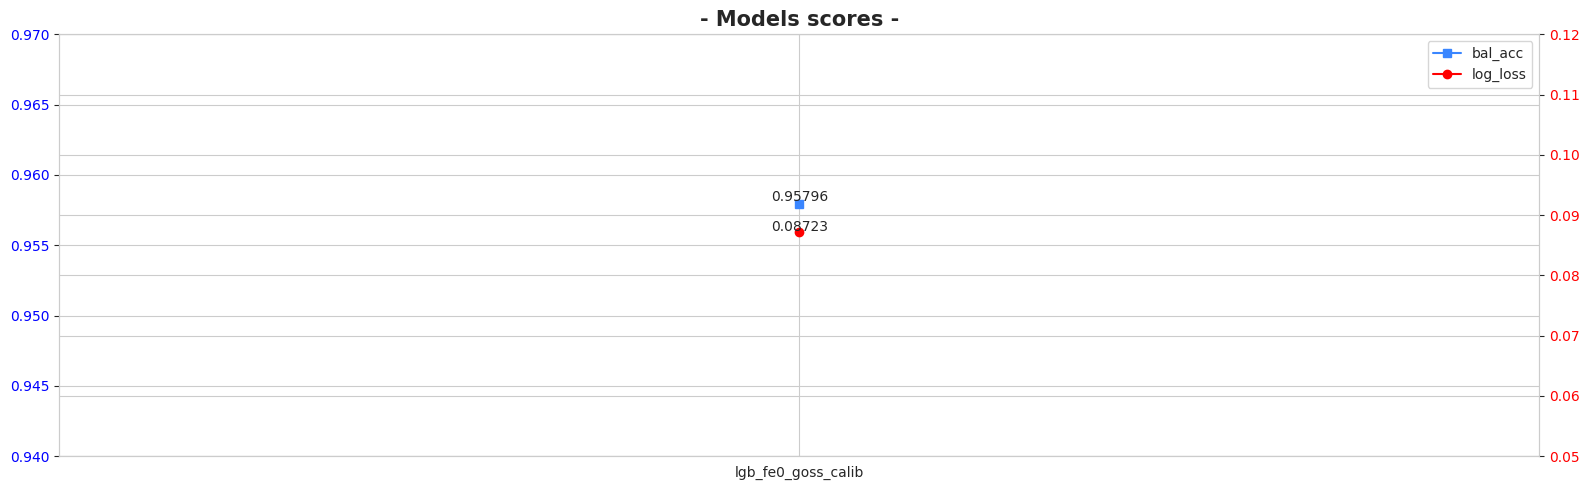

In [55]:
_scores = [*result_scores.values()]
_losses = [*result_losses.values()]

y_add = 2e-4

fig, ax1 = plt.subplots(1, 1, figsize=(16, 5))

plot_1 = ax1.plot(_scores, marker='s', label='bal_acc')
ax1.tick_params(axis='y', labelcolor='b')
for i, s1 in enumerate(_scores):
    ax1.text(float(i), s1+y_add, s1, ha='center', va='baseline')
    
ax1.set_title('- Models scores -', fontdict={'weight': 'semibold', 'size': 15})
ax1.set_xticks(range(len(result_names)), result_names, rotation=0)

ax2 = ax1.twinx()
plot_2 = ax2.plot(_losses, marker='o', label='log_loss', color='r')
ax2.tick_params(axis='y', labelcolor='r')

for i, s2 in enumerate(_losses):
    ax2.text(float(i), s2+y_add, s2, ha='center', va='baseline')
    
ax1.set_ylim((0.94, 0.97))
ax2.set_ylim((0.05, 0.12))

handle = plot_1 + plot_2
labels = [l.get_label() for l in handle]
ax1.legend(handle, labels, loc='best')

plt.tight_layout()
plt.show()

In [56]:
## -- Plot feature importances --
top_n = 30

for i, (m, fi) in enumerate(result_importances.items()):
    if 'calib' in m:
        continue
    else:
        plt.figure(figsize=(16, 8))
        fi_df = pd.DataFrame({
            'feature': result_data[m][0].columns,
            'importance': fi,
        }).sort_values(by='importance', ascending=False).reset_index(drop=True).head(top_n)
        
        sns.barplot(data=fi_df, x='importance', y='feature')
        plt.title(f'Avg. {CFG['FOLDS']}-Fold feature importances: {m}', fontweight='semibold')
        plt.tight_layout() 
        plt.show()
    
        print()

In [57]:
## -- Get OOF predictions --
for i, (k, v) in enumerate(result_oof.items()):
    n = f"{k}_{str(_scores[i]).split('.')[1]}"
    np.save(f"oof_{n}_.npy", v)
    print(f"oof {n} saved!")

oof lgb_fe0_goss_calib_95796 saved!


Submission lgb_fe0_goss_calib_95796 file saved! (247435,)


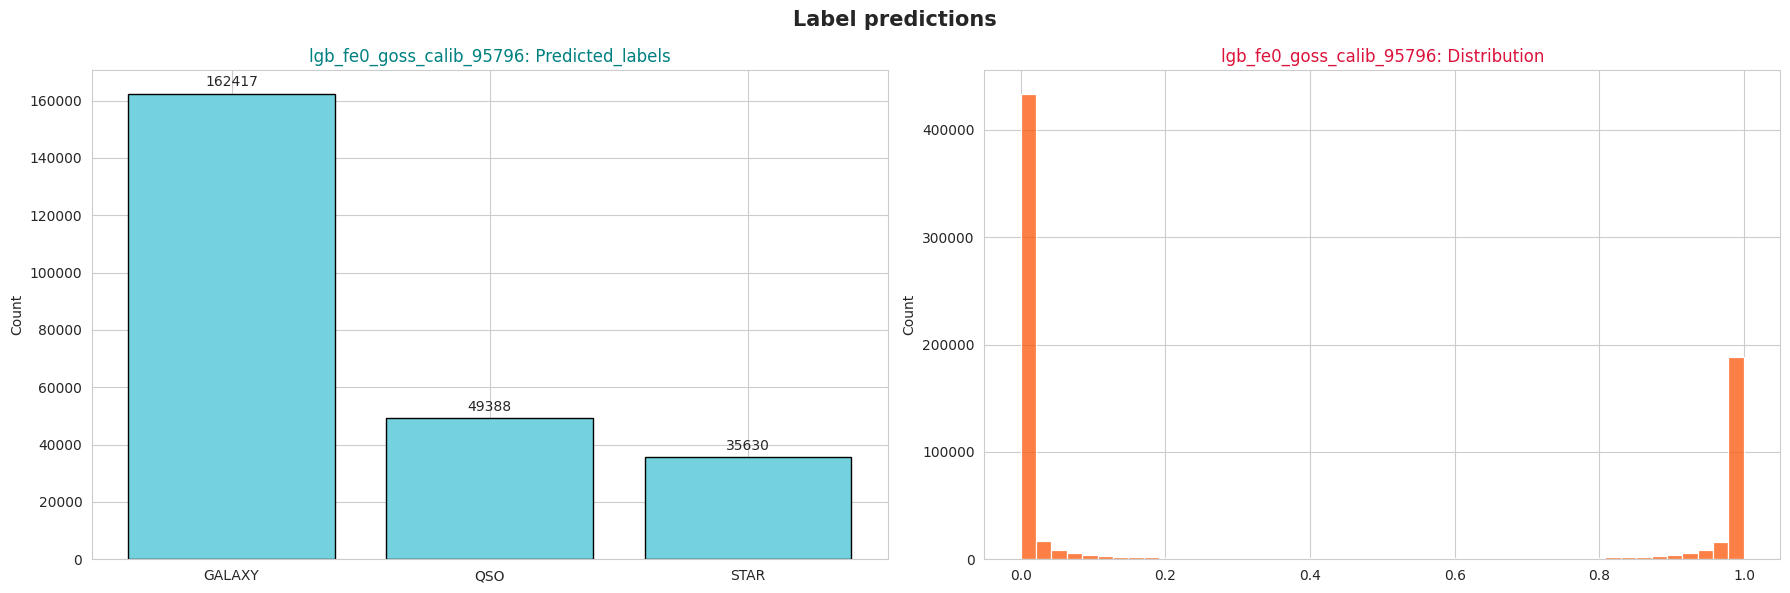

In [58]:
## -- Get TEST predictions / submission --
model_results ={}

for i, (k, v) in enumerate(result_test.items()):
    ## -- Base submission --
    n = f"{k}_{str(_scores[i]).split('.')[1]}"
    np.save(f"test_{n}_.npy", v)
    
    _preds = np.argmax(v, axis=1)
    
    submit[TARGET] = pd.Series(_preds).map(r_mapping)
    submit.to_csv(f"submit_{n}.csv", index=False)
    print(f"Submission {n} file saved! {_preds.shape}")
    
    model_results[n] = submit[TARGET]

    ## --- Plot predictions ----
    counts = [np.sum(_preds == _) for _ in range(len(np.unique(_preds)))]

    fig, axs = plt.subplots(1, 2, figsize=(18, 6))
    axs[0].bar([*mapping.keys()], counts, color='#73D2DE', edgecolor='k')
    axs[0].set_title(f"{n}: Predicted_labels", color='teal')
    axs[0].set_ylabel('Count')

    for i, c in enumerate(counts):
        axs[0].text(i, c+2500, str(c), ha='center', fontsize=10)

    sns.histplot(v.ravel(), ax=axs[1], color='#FB5607')
    axs[1].set_title(f"{n}: Distribution", color='crimson')
    
    plt.suptitle('Label predictions', fontsize=15, fontweight='semibold')
    plt.tight_layout()
    plt.show()

    print()

In [59]:
final_results = pd.DataFrame(model_results)
final_results

,lgb_fe0_goss_calib_95796
0,GALAXY
1,GALAXY
2,GALAXY
3,STAR
4,GALAXY
...,...
247430,QSO
247431,QSO
247432,GALAXY
247433,QSO


In [60]:
# !rm -r /kaggle/working